# Plotting ROIs - Figure 2

Working with classes from `region_plotting.py`

In [ ]:
import matplotlib as mpl
import pandas as pd
import bioframe as bf

from modules.region_plotting import RegionPlotter
from modules.germany import germany

In [2]:
mpl.rcParams.update({'pdf.fonttype': 42,
                     'ps.fonttype': 42,
                     'xtick.labelsize': 12,
                     'ytick.labelsize': 12,
                     'axes.labelsize': 12,
                     'font.size': 12
                    })

## Set parameters

In [3]:
fig2_region = ('chr5', 171_800_000, 174_800_000)

# hi-c
resolution = 10_000
max_separation = 1_500_000
hic_vmin = 3e-4
hic_vmax = 3e-1

g2_path = '/groups/gerlich/experiments/Experiments_006500/006575/coolers_repo/WT_G2/WT_G2.all.mcool'

#tads
tads = bf.read_table('/groups/gerlich/experiments/Experiments_006300/006326/data/output/02_ontad_penalty_selection/ontad.minsz_5.maxsz_400.penalty_0.1.bedpe', schema='bed3')

# chip-seq
binsize = 2000
chip_vmin = None
chip_vmax = None
rad21_g2 = '/groups/gerlich/experiments/Experiments_006500/006575/bam_repo/RAD21/WT_G2/RAD21_WT_G2.chip.bw'
sor_g2 = '/groups/gerlich/experiments/Experiments_006500/006575/bam_repo/Sororin/WT_G2/Sororin_WT_G2.chip.bw'

# boundaries
level_colors = {'high': 'red', 'med': 'green', 'low': 'blue'}
hue = 'levelGroup'
boundaries_df = pd.read_parquet('/groups/gerlich/labinfo/Papers/2025_ReplChromConf/analysis/assets/tads_annot/boundaries.parquet')

/srv/conda/envs/notebook/lib/python3.10/site-packages/bioframe/io/fileops.py:75: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv(filepath_or, **kwargs)


### Figure 2A - Plot Hi-C

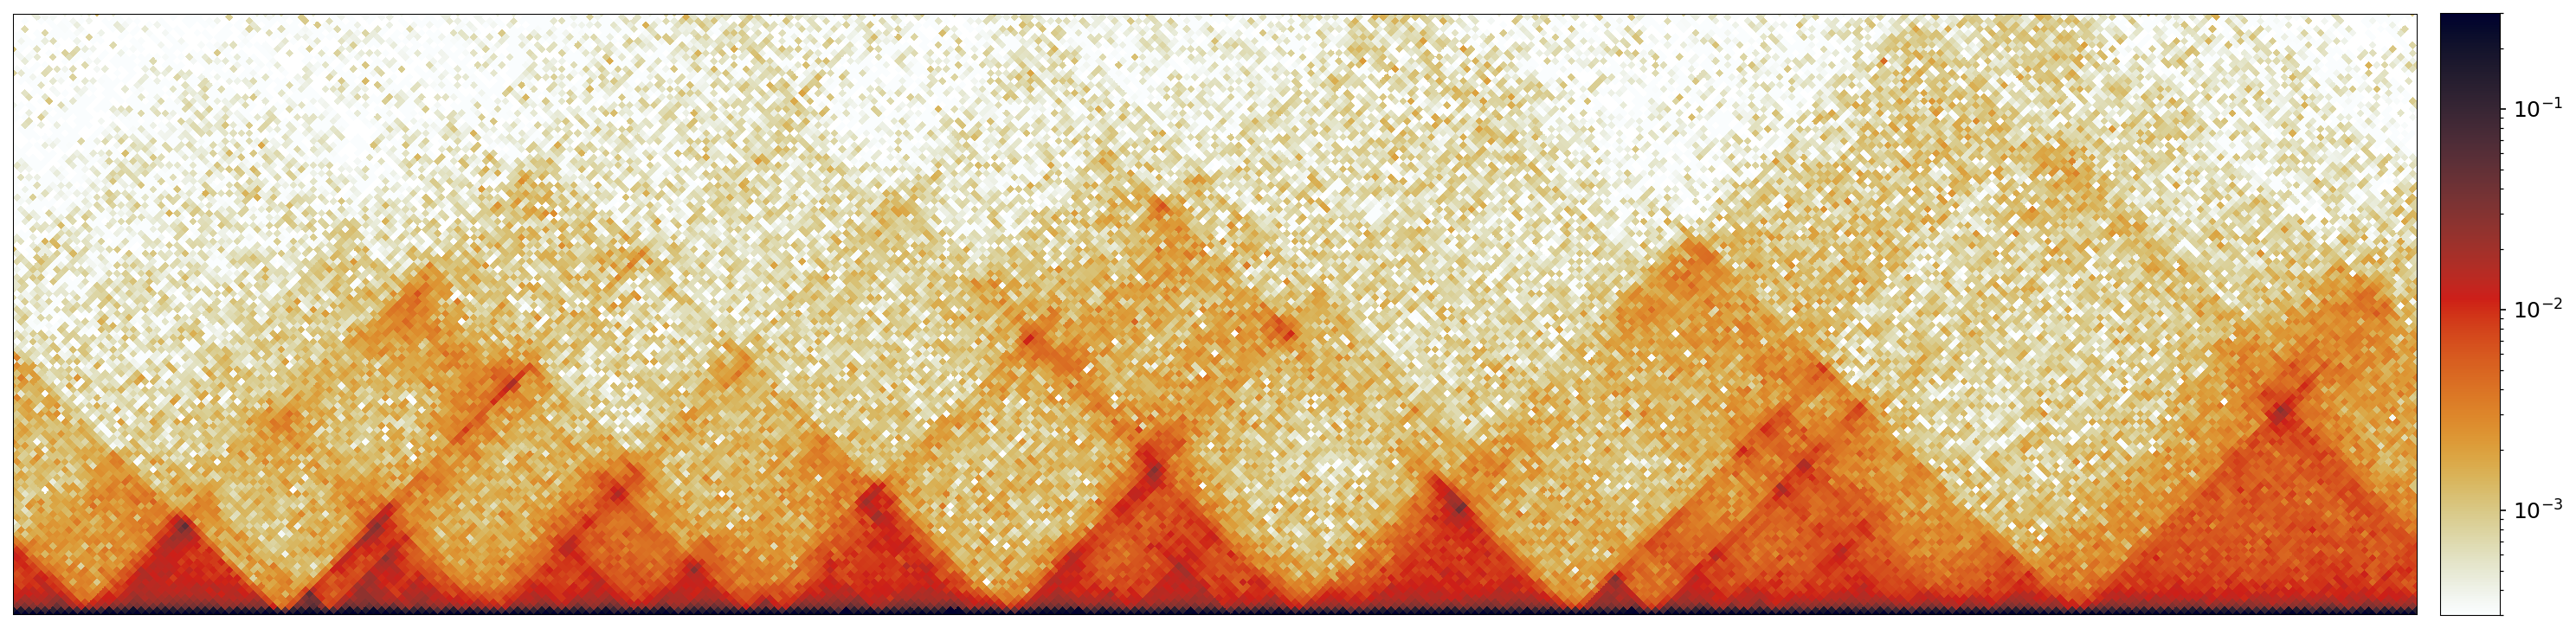

In [4]:
fig2_plotter = RegionPlotter(*fig2_region)

fig2_plotter.add_hic(g2_path, resolution, hic_vmin, hic_vmax, max_separation, germany, height=1)

fig, axes = fig2_plotter.plot(figsize=(20, 5), dpi=150, tick_all=False, tick_step=100_000)
axes[0,0].set_yticks([]) # change yticks on the Hi-C track
axes[0,0].set_yticklabels([]) # rename yticks on the Hi-C track
axes[0,0].set_xticks([])
axes[0,0].set_xticklabels([])

for ax in axes.flat:
    # Set border linewidth and make all spines visible
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)  # Adjust linewidth as needed
        spine.set_visible(True)  # Ensure all borders are visible

for ax in axes.flat:
    ax.set_xlabel('')  # Remove x-axis label

fig.tight_layout()

### Figure 2B - Plot ChIP-Seq

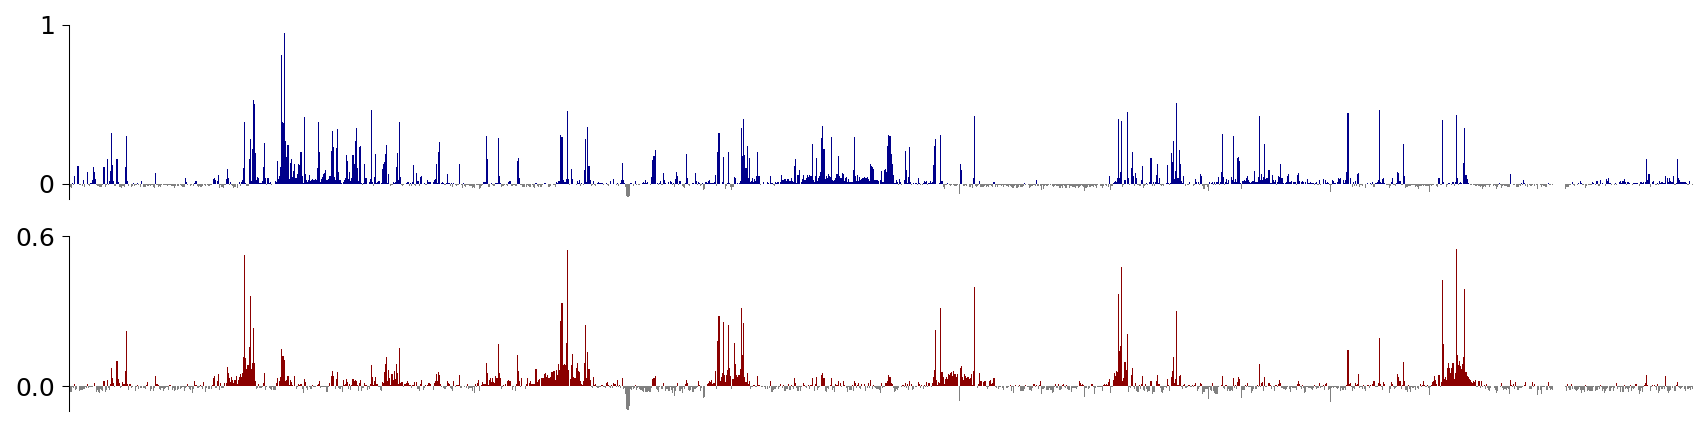

In [9]:
fig2_plotter = RegionPlotter(*fig2_region)

fig2_plotter.add_fill(rad21_g2, binsize, -0.1, 1, 'grey', 'darkblue', mean_subtract=True, height=1)
fig2_plotter.add_fill(sor_g2, binsize, -0.1, 0.6, 'grey', 'darkred', mean_subtract=True, height=1)


fig, axes = fig2_plotter.plot(figsize=(12, 3), dpi=150, tick_all=False, tick_step=1_000_000)

for i in range(2):
    for spine in axes[i, 0].spines.values():
        spine.set_linewidth(0.5)
    axes[i, 0].tick_params(width=0.5)
    # Adjust y axes
    axes[i, 0].set_xticks([]) # change yticks
    axes[i, 0].set_xticklabels([])
    axes[i,0].xaxis.set_visible(False)
    axes[i, 0].spines['bottom'].set_visible(False) # Remove the horizontal line

# Adjust y axes
axes[0, 0].set_yticks([0, 1])
axes[1, 0].set_yticks([0, 0.6])
fig.tight_layout()

### Figure 2C - Plot TAD annotations

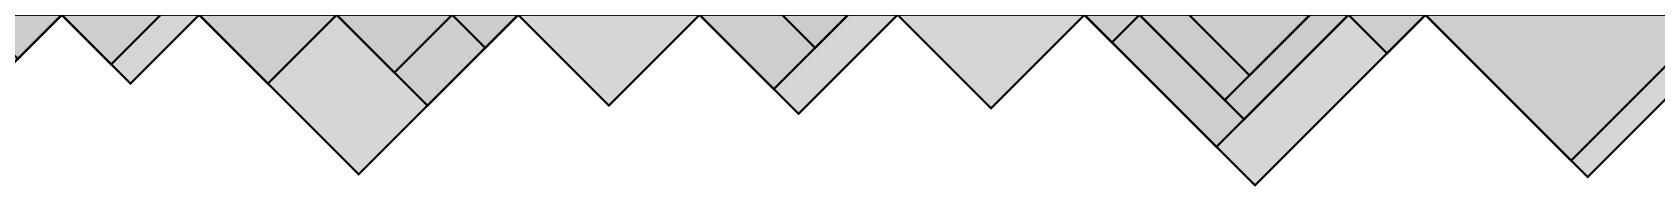

In [6]:
fig2_plotter = RegionPlotter(*fig2_region)

fig2_plotter.add_tads(tads, facecolor='.8', edgecolor='k', facealpha=.8, edgealpha=1, orient='down', height=4)

fig, axes = fig2_plotter.plot(figsize=(16, 5), dpi=150)

for ax in axes.flat:
    # Set border linewidth and make all spines visible
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)  # Adjust linewidth as needed
        spine.set_visible(True)  # Ensure all borders are visible

### Figure 2C - Plot Boundaries

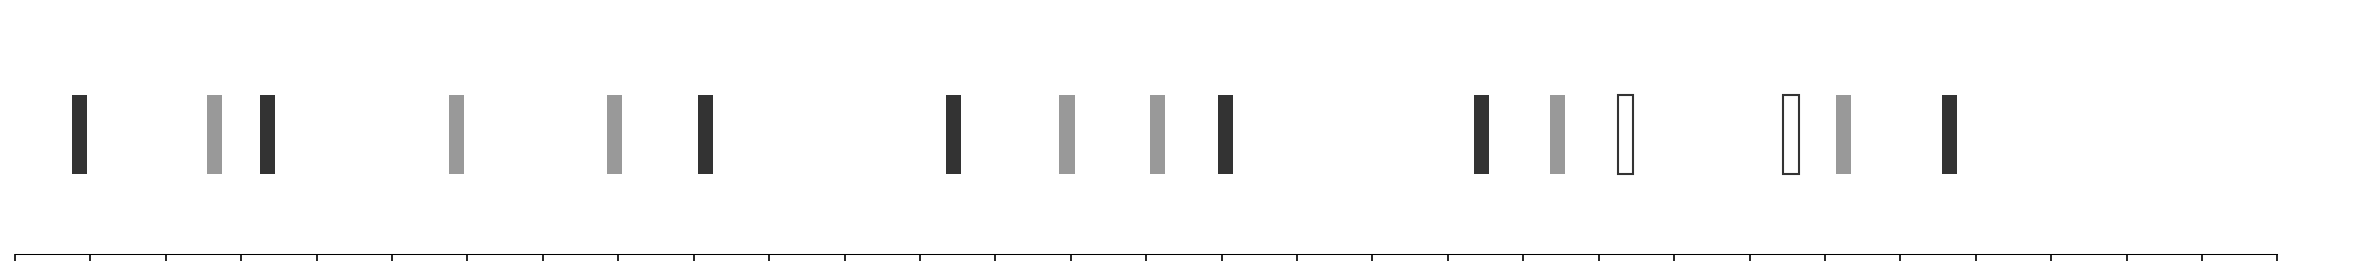

In [7]:
fig2_plotter = RegionPlotter(*fig2_region)

new_level_colors = {'high': 'k', 'med': '.5', 'low': 'w'}
edge_colors = {'high': None, 'med': None, 'low': 'k'}
fig2_plotter.add_df_multi(boundaries_df, hue, new_level_colors, edgecolors=edge_colors, stratify=False, pad=5_000, height=1)

fig, axes = fig2_plotter.plot(figsize=(16, 2), dpi=150, tick_all=False, tick_step=100_000)
for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.yaxis.set_visible(False)
    ax.set_xticklabels([])  # Remove x-axis tick labels
    ax.spines['bottom'].set_linewidth(0.5)
    legend = ax.get_legend()
    if legend:
        legend.remove() # 

fig.tight_layout()